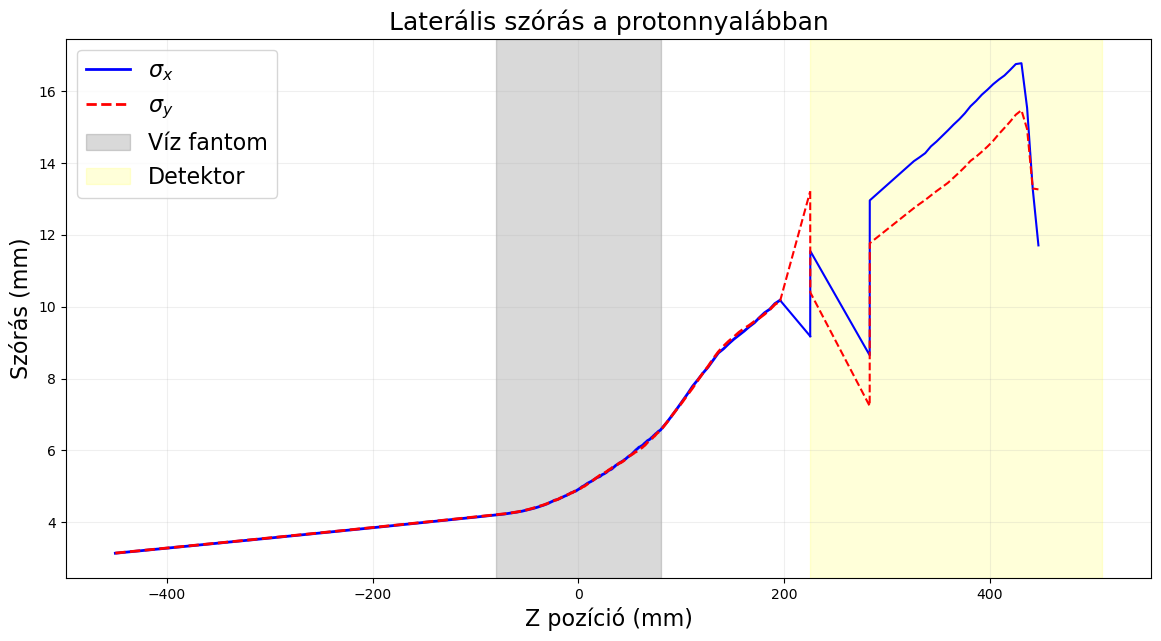

In [ ]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fájlok betöltése
particle = 'proton'
PSAFile = f'PSA-{particle}.root'
TrackerFile = f'Hits-track-{particle}.root'
CalorimeterFile = f'Hits-calor-{particle}.root'

# PSA és Hits (Detektor) beolvasása, összefűzése
with uproot.open(PSAFile) as f: df_psa = f[f.keys()[0]].arrays(library='pd')
with uproot.open(TrackerFile) as f: df_tr = f[f.keys()[0]].arrays(library='pd')
with uproot.open(CalorimeterFile) as f: df_cal = f[f.keys()[0]].arrays(library='pd')

# Csak elsődlegesek
df_psa = df_psa[df_psa['ParentID']==0]
df_det = pd.concat([df_tr, df_cal], ignore_index=True)
df_det = df_det[df_det['ParentID']==0]

# Statisztika (PSA + Hits)
psa_stats = df_psa.groupby(np.round(df_psa['PostPosition_Z'], 0)).agg({'PostPosition_X': 'std', 'PostPosition_Y': 'std'})
det_stats = df_det.groupby(np.round(df_det['PostPosition_Z'], 1)).agg({'PostPosition_X': 'std', 'PostPosition_Y': 'std'})



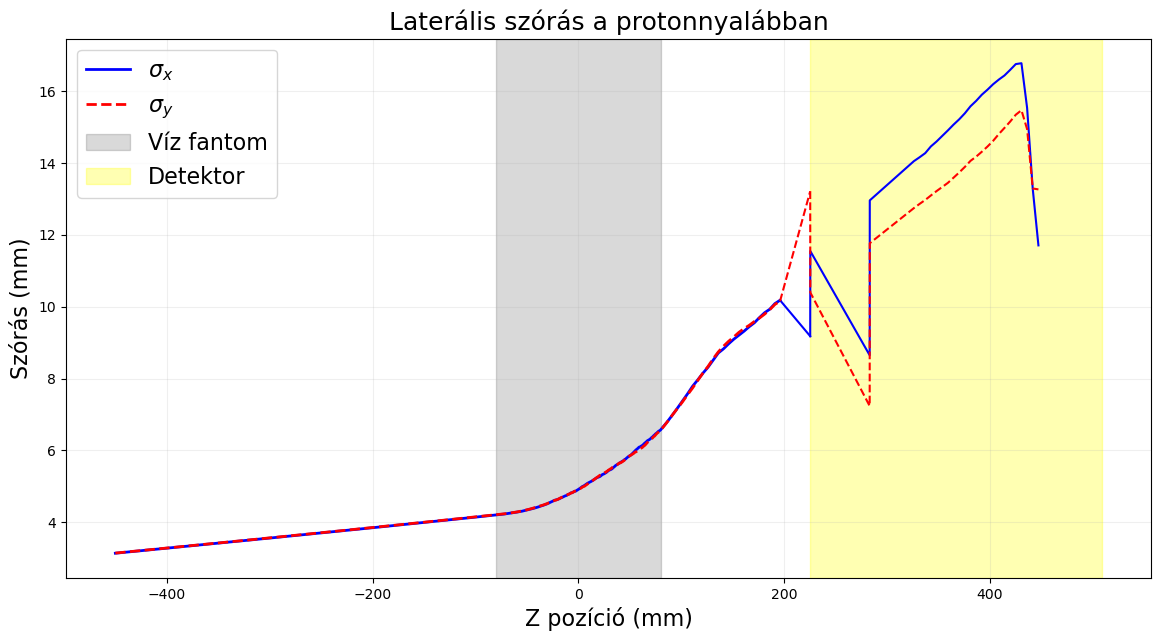

In [20]:
plt.figure(figsize=(14, 7))
# PSA szakasz
plt.plot(psa_stats.index, psa_stats['PostPosition_X'], color='blue', label=r'$\sigma_x$', lw=2)
plt.plot(psa_stats.index, psa_stats['PostPosition_Y'], color='red', label=r'$\sigma_y$', lw=2, ls='--')

# Detektor szakasz (pontokkal)
plt.plot(det_stats.index, det_stats['PostPosition_X'], color='blue')
plt.plot(det_stats.index, det_stats['PostPosition_Y'], color='red', ls='--')

# Összekötő "híd"
plt.plot([psa_stats.index[-1], det_stats.index[0]], [psa_stats['PostPosition_X'].iloc[-1], det_stats['PostPosition_X'].iloc[0]], color='blue')
plt.plot([psa_stats.index[-1], det_stats.index[0]], [psa_stats['PostPosition_Y'].iloc[-1], det_stats['PostPosition_Y'].iloc[0]], color='red', ls='--')

plt.axvspan(-80, 80, color='black', alpha=0.15, label='Víz fantom')
plt.axvspan(det_stats.index.min(), det_stats.index.min() + 57.8 + 41 * 5.5, color='yellow', alpha=0.30, label='Detektor')

plt.title("Laterális szórás a protonnyalábban", fontsize=18)
plt.xlabel("Z pozíció (mm)", fontsize=16); plt.ylabel("Szórás (mm)", fontsize=16)
plt.legend(loc='upper left', fontsize=16); plt.grid(True, alpha=0.2)
plt.show()

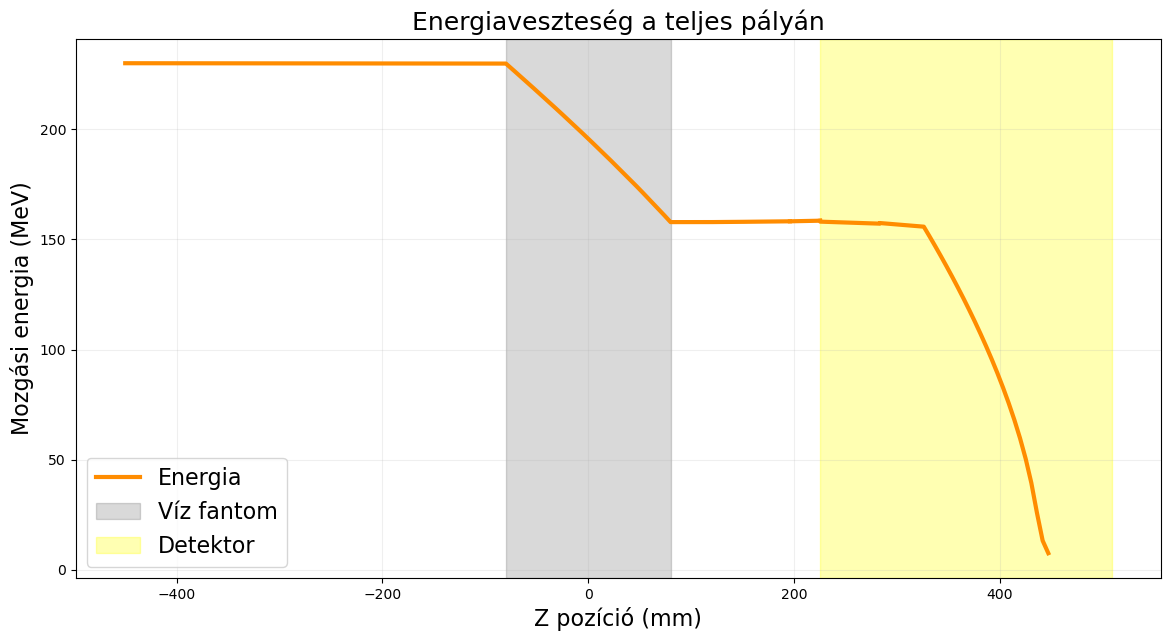

In [21]:
# Statisztika az energiához
psa_energy = df_psa.groupby(np.round(df_psa['PostPosition_Z'], 0)).agg({'KineticEnergy': 'mean'})
det_energy = df_det.groupby(np.round(df_det['PostPosition_Z'], 1)).agg({'KineticEnergy': 'mean'})

plt.figure(figsize=(14, 7))
# PSA vonal
plt.plot(psa_energy.index, psa_energy['KineticEnergy'], color='darkorange', lw = 3, label='Energia')
# Detektor pontok
plt.plot(det_energy.index, det_energy['KineticEnergy'], color='darkorange', lw = 3, zorder=5)

# Összekötő "híd"
plt.plot([psa_energy.index[-1], det_energy.index[0]], [psa_energy['KineticEnergy'].iloc[-1], det_energy['KineticEnergy'].iloc[0]], lw = 3, color='darkorange')

plt.axvspan(-80, 80, color='black', alpha=0.15, label='Víz fantom')
plt.axvspan(det_energy.index.min(), det_energy.index.min() + 57.8 + 41 * 5.5, color='yellow', alpha=0.30, label='Detektor')
plt.title("Energiaveszteség a teljes pályán", fontsize=18)
plt.xlabel("Z pozíció (mm)", fontsize=16); plt.ylabel("Mozgási energia (MeV)", fontsize=16)
plt.legend(fontsize=16); plt.grid(True, alpha=0.2)
plt.show()

Adatok beolvasása az új (1e5) fájlokból...
Statisztika kiszámítása...
Ábrázolás...


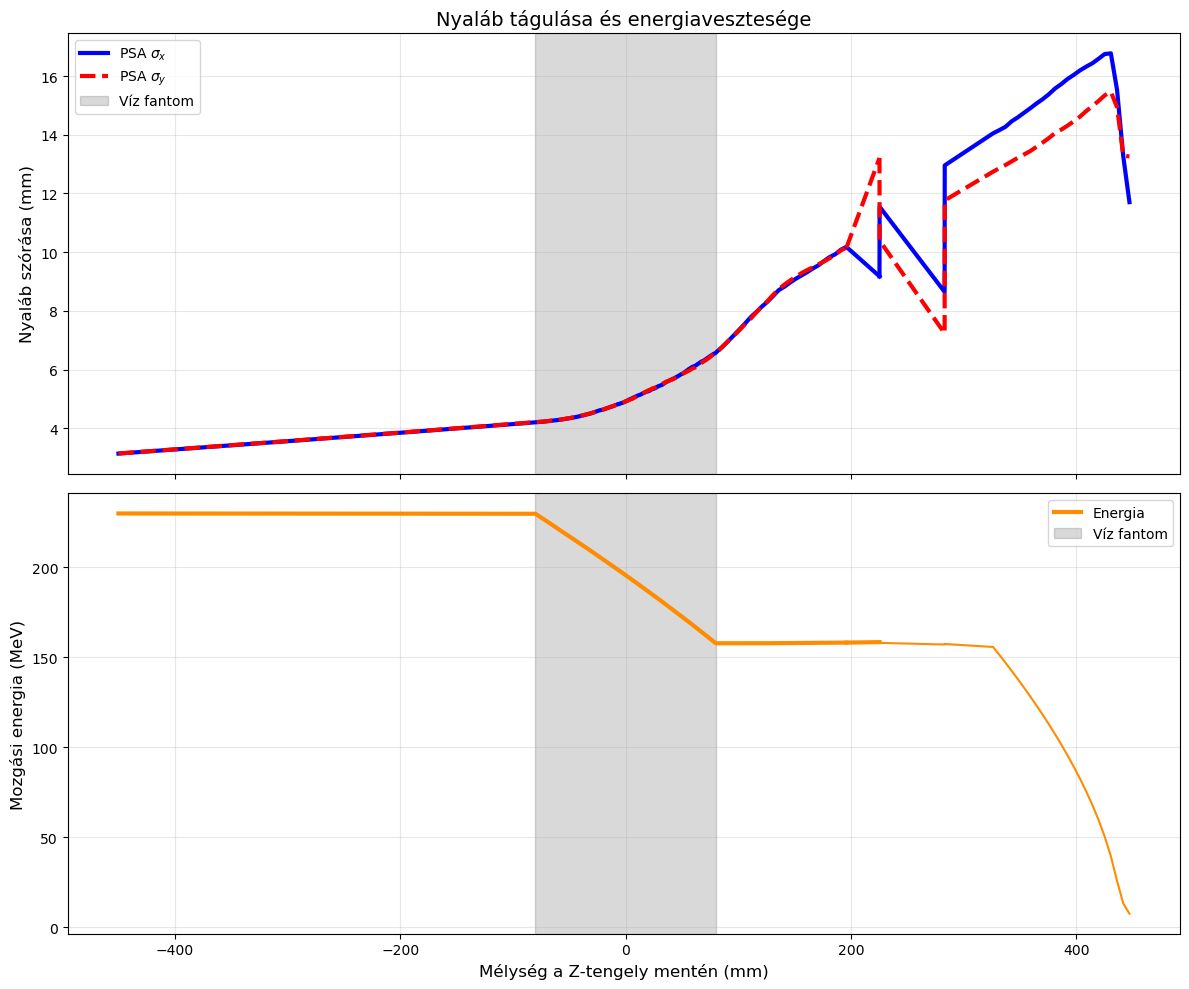

In [ ]:
'''
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

particle = 'proton'
TrackerFile = f'Hits-track-{particle}.root'
CalorimeterFile = f'Hits-calor-{particle}.root'
PSAFile = f'PSA-{particle}.root'

print("Adatok beolvasása az új (1e5) fájlokból...")

# --- 1. PSA (Fantom) adatok beolvasása ---
with uproot.open(PSAFile) as file:
    df_psa = file[file.keys()[0]].arrays(library='pd')
df_psa = df_psa[df_psa['ParentID'] == 0]

# --- 2. Hits (Detektor) adatok beolvasása és összefűzése ---
with uproot.open(TrackerFile) as file:
    df_track = file[file.keys()[0]].arrays(library='pd')
with uproot.open(CalorimeterFile) as file:
    df_calor = file[file.keys()[0]].arrays(library='pd')

df_hits = pd.concat([df_track, df_calor], ignore_index=True)
df_hits = df_hits[df_hits['ParentID'] == 0].copy()
del [df_track, df_calor]

print("Statisztika kiszámítása...")

# --- 3. Statisztika (Átlag energia és Szórás rétegenként) ---
df_psa['Z_slice'] = np.round(df_psa['PostPosition_Z'], 0)
psa_stats = df_psa.groupby('Z_slice').agg({
    'PostPosition_X': 'std',
    'PostPosition_Y': 'std',
    'KineticEnergy': 'mean'
})

df_hits['Z_slice'] = np.round(df_hits['PostPosition_Z'], 1)
hits_stats = df_hits.groupby('Z_slice').agg({
    'PostPosition_X': 'std',
    'PostPosition_Y': 'std',
    'KineticEnergy': 'mean'
})

# --- Összekötő "híd" a PSA vége és a Hits eleje között ---
z_bridge = [psa_stats.index[-1], hits_stats.index[0]]
sigx_bridge = [psa_stats['PostPosition_X'].iloc[-1], hits_stats['PostPosition_X'].iloc[0]]
sigy_bridge = [psa_stats['PostPosition_Y'].iloc[-1], hits_stats['PostPosition_Y'].iloc[0]]
energy_bridge = [psa_stats['KineticEnergy'].iloc[-1], hits_stats['KineticEnergy'].iloc[0]]

print("Ábrázolás...")

# --- 4. ÁBRÁZOLÁS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- FELSŐ ÁBRA: SZÓRÁS ---
ax1.plot(psa_stats.index, psa_stats['PostPosition_X'], label=r'PSA $\sigma_x$', color='blue', lw=3)
ax1.plot(psa_stats.index, psa_stats['PostPosition_Y'], label=r'PSA $\sigma_y$', color='red', lw=3, linestyle='--')

ax1.plot(z_bridge, sigx_bridge, color='blue', lw = 3)
ax1.plot(z_bridge, sigy_bridge, color='red', linestyle = '--', lw = 3)

ax1.plot(hits_stats.index, hits_stats['PostPosition_X'], lw = 3, color='blue', zorder=5)
ax1.plot(hits_stats.index, hits_stats['PostPosition_Y'], lw = 3, color='red', linestyle='--', zorder=5)

ax1.axvspan(-80, 80, color='black', alpha=0.15, label='Víz fantom')
ax1.set_ylabel("Nyaláb szórása (mm)", fontsize=12)
ax1.set_title("Nyaláb tágulása és energiavesztesége", fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- ALSÓ ÁBRA: ENERGIA ---
ax2.plot(psa_stats.index, psa_stats['KineticEnergy'], color='darkorange', lw = 3, label='Energia')
ax2.plot(z_bridge, energy_bridge, color='darkorange', lw = 3)
ax2.plot(hits_stats.index, hits_stats['KineticEnergy'], color='darkorange', zorder=5)

ax2.axvspan(-80, 80, color='black', alpha=0.15, label='Víz fantom')
ax2.set_xlabel("Mélység a Z-tengely mentén (mm)", fontsize=12)
ax2.set_ylabel("Mozgási energia (MeV)", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
'''

Detektor adatok beolvasása...
Szűrés és irányvektor számítása...
PSA adatok (fantom) feldolgozása...
2D Hisztogram ábrázolása...


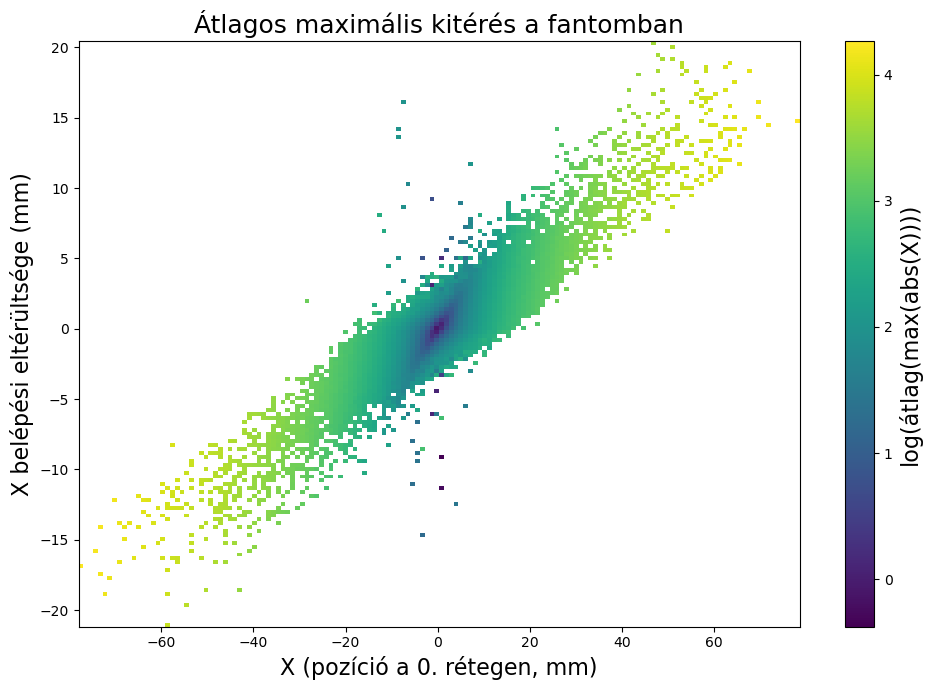

In [ ]:
import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

# --- 1. Fájlnevek beállítása ---
particle = 'proton'
TrackerFile = f'Hits-track-{particle}.root'
CalorimeterFile = f'Hits-calor-{particle}.root'
PSAFile = f'PSA-{particle}.root'

print("Detektor adatok beolvasása...")

# --- 2. Tracker adatok (0. és 1. réteg) ---
with uproot.open(TrackerFile) as file:
    first_key = file.keys()[0]
    df_hits_track = file[first_key].arrays(library='pd')

df_hits_track = df_hits_track[df_hits_track['ParentID'] == 0][['KineticEnergy', 'PostPosition_X', 'PostPosition_Y', 'PostPosition_Z', 'EventID', 'PreStepUniqueVolumeID']]
df_hits_track['Layer'] = [int(val.split('_')[-2]) for val in df_hits_track['PreStepUniqueVolumeID'].astype(str)]
df_hits_track.drop(columns=['PreStepUniqueVolumeID'], inplace=True)

# --- 3. Kaloriméter adatok (2. rétegtől) ---
with uproot.open(CalorimeterFile) as file:
    first_key = file.keys()[0]
    df_hits_calor = file[first_key].arrays(library='pd')

df_hits_calor = df_hits_calor[df_hits_calor['ParentID'] == 0][['KineticEnergy', 'PostPosition_X', 'PostPosition_Y', 'PostPosition_Z', 'EventID', 'PreStepUniqueVolumeID']]
df_hits_calor['Layer'] = [2 + int(val.split('_')[-2]) for val in df_hits_calor['PreStepUniqueVolumeID'].astype(str)]
df_hits_calor.drop(columns=['PreStepUniqueVolumeID'], inplace=True)

# Összefűzés és takarítás
df_hits = pd.concat([df_hits_track, df_hits_calor], ignore_index=True)
del [df_hits_track, df_hits_calor]

print("Szűrés és irányvektor számítása...")

# --- 4. Túlélési szűrés és Vektorok ---
max_layers = df_hits.groupby('EventID')['Layer'].max().rename('MaxLayer')

layer0 = df_hits[df_hits['Layer'] == 0][['EventID', 'PostPosition_X', 'PostPosition_Y', 'KineticEnergy']]
layer1 = df_hits[df_hits['Layer'] == 1][['EventID', 'PostPosition_X', 'PostPosition_Y']]
merged = pd.merge(layer0, layer1, on='EventID', suffixes=('_L0', '_L1'))

df_hits_selected = pd.DataFrame()
df_hits_selected['EventID'] = merged['EventID']
df_hits_selected[['X', 'Y', 'KineticEnergy']] = merged[['PostPosition_X_L0', 'PostPosition_Y_L0', 'KineticEnergy']]
df_hits_selected['Dir_X'] = merged['PostPosition_X_L1'] - merged['PostPosition_X_L0']
df_hits_selected['Dir_Y'] = merged['PostPosition_Y_L1'] - merged['PostPosition_Y_L0']

df_hits_selected = df_hits_selected.merge(max_layers, on='EventID', how='left')

l_max = max_layers.max()
l_min = l_max - 4
# Kiszórjuk azokat, amik túl korán elvesztek
df_hits_selected.drop(index=df_hits_selected.index[df_hits_selected['MaxLayer'] <= l_min], inplace=True)

print("PSA adatok (fantom) feldolgozása...")

# --- 5. PSA fantom adatok ---
with uproot.open(PSAFile) as file:
    first_key = file.keys()[0]
    df_psa = file[first_key].arrays(library='pd')

df_psa = df_psa[df_psa['ParentID'] == 0][['PostPosition_X', 'PostPosition_Y', 'EventID']]

# Max abszolút kitérés megkeresése
psa_max = df_psa.set_index('EventID').abs().groupby('EventID').max().reset_index()
psa_max.rename(columns={'PostPosition_X': 'maxabs_X', 'PostPosition_Y': 'maxabs_Y'}, inplace=True)

df_hits_selected = pd.merge(df_hits_selected, psa_max, on='EventID', how='left')

print("Korreláció számítása és 2D Hisztogram ábrázolása...")

# --- ÚJ: Outlier szűrés a robusztusabb illesztéshez ---
# Eltávolítjuk az extrém 1-1%-ot, ami "zajként" elhúzza a lineáris illesztést
q_x = df_hits_selected['X'].quantile([0.01, 0.99])
q_dir = df_hits_selected['Dir_X'].quantile([0.01, 0.99])

df_fit = df_hits_selected[
    (df_hits_selected['X'] > q_x[0.01]) & (df_hits_selected['X'] < q_x[0.99]) &
    (df_hits_selected['Dir_X'] > q_dir[0.01]) & (df_hits_selected['Dir_X'] < q_dir[0.99])
]

# Korreláció számítása csak a sűrű magra (tisztított adatok)
corr_value = df_fit['X'].corr(df_fit['Dir_X'])
print(f"Tisztított Pearson-féle korrelációs együttható: {corr_value:.3f}")

# Lineáris regresszió (y = m*x + b) a tisztított adatokon
m, b = np.polyfit(df_fit['X'], df_fit['Dir_X'], 1)

# A vonal kirajzolásához az eredeti szélességet használjuk, hogy végigérjen az ábrán
x_fit = np.linspace(df_hits_selected['X'].min(), df_hits_selected['X'].max(), 100)
y_fit = m * x_fit + b

# --- 6. 2D Binned Statistic Ábra ---
ret = binned_statistic_2d(df_hits_selected['X'], df_hits_selected['Dir_X'], np.log(df_hits_selected['maxabs_X']), statistic='mean', bins=150)

plt.figure(figsize=(10, 7))
im = plt.pcolormesh(ret.x_edge, ret.y_edge, ret.statistic.T, cmap='viridis')
cbar = plt.colorbar(im)
cbar.set_label('log(átlag(max(abs(X))))', fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Trendvonal kirajzolása
plt.plot(x_fit, y_fit, color='red', linestyle='--', linewidth=3, label=f'Trendvonal ($\\rho$ = {corr_value:.3f})')

plt.xlabel('X (pozíció a 0. rétegen, mm)', fontsize=16)
plt.ylabel('Irány ($X_1 - X_0$ [mm])', fontsize=16)
plt.title('Átlagos maximális kitérés a fantomban', fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(fontsize=14, loc='upper left')

plt.tight_layout()
plt.show()

In [14]:
# 1. Mennyi volt az átlagos kitérés az összes protonnál?
eredeti_atlag = df_hits_selected['maxabs_X'].mean()
print(f"Eredeti átlagos kitérés a vízben (szűrés nélkül): {eredeti_atlag:.3f} mm")

# 2. VÁGÁS (CUT): Csak a középső, legjobb protonokat tartjuk meg!
# Kidobjuk azokat, amik a detektor legszélére érkeztek (X > 20 vagy X < -20)
# És kidobjuk a túl nagy szögben érkezőket (Dir_X > 5 vagy Dir_X < -5)
df_cut = df_hits_selected[
    (df_hits_selected['X'].abs() < 6) & 
    (df_hits_selected['Dir_X'].abs() < 12)
]

# 3. Mennyi az átlagos kitérés a vágás után?
vagott_atlag = df_cut['maxabs_X'].mean()
print(f"Vágott átlagos kitérés a vízben (csak a 'jó' protonok): {vagott_atlag:.3f} mm")

# Javulás mértéke
javulas = (eredeti_atlag - vagott_atlag) / eredeti_atlag * 100
print(f"--> Sikerült {javulas:.1f}%-kal csökkenteni a szóródási hibát a vágással!")
print(f"--> Megmaradt protonok száma: {len(df_cut)} db (Eredeti: {len(df_hits_selected)} db)")

Eredeti átlagos kitérés a vízben (szűrés nélkül): 6.751 mm
Vágott átlagos kitérés a vízben (csak a 'jó' protonok): 3.704 mm
--> Sikerült 45.1%-kal csökkenteni a szóródási hibát a vágással!
--> Megmaradt protonok száma: 38843 db (Eredeti: 68804 db)


Proton Radiográfia (2D vetületi kép) generálása...


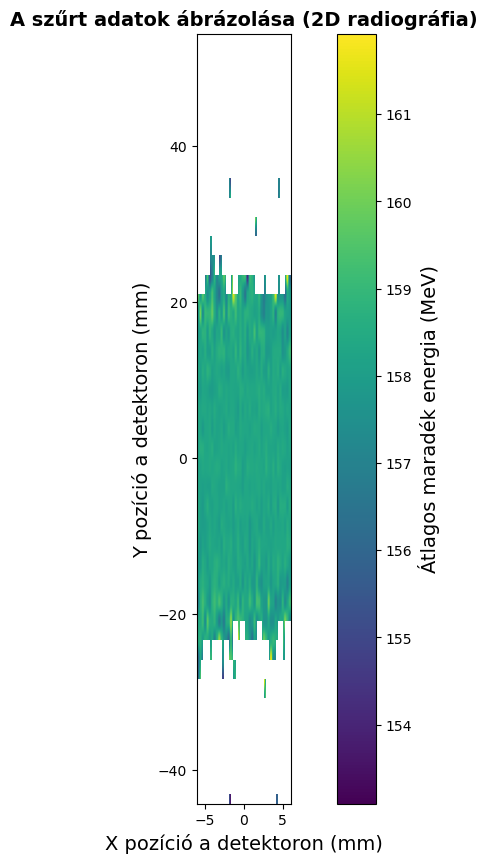


Statisztika számítása a teljes detektorhosszra a 2D vágás alapján...
Eredeti protonok száma: 68804 db
Vágás utáni protonok száma: 38843 db


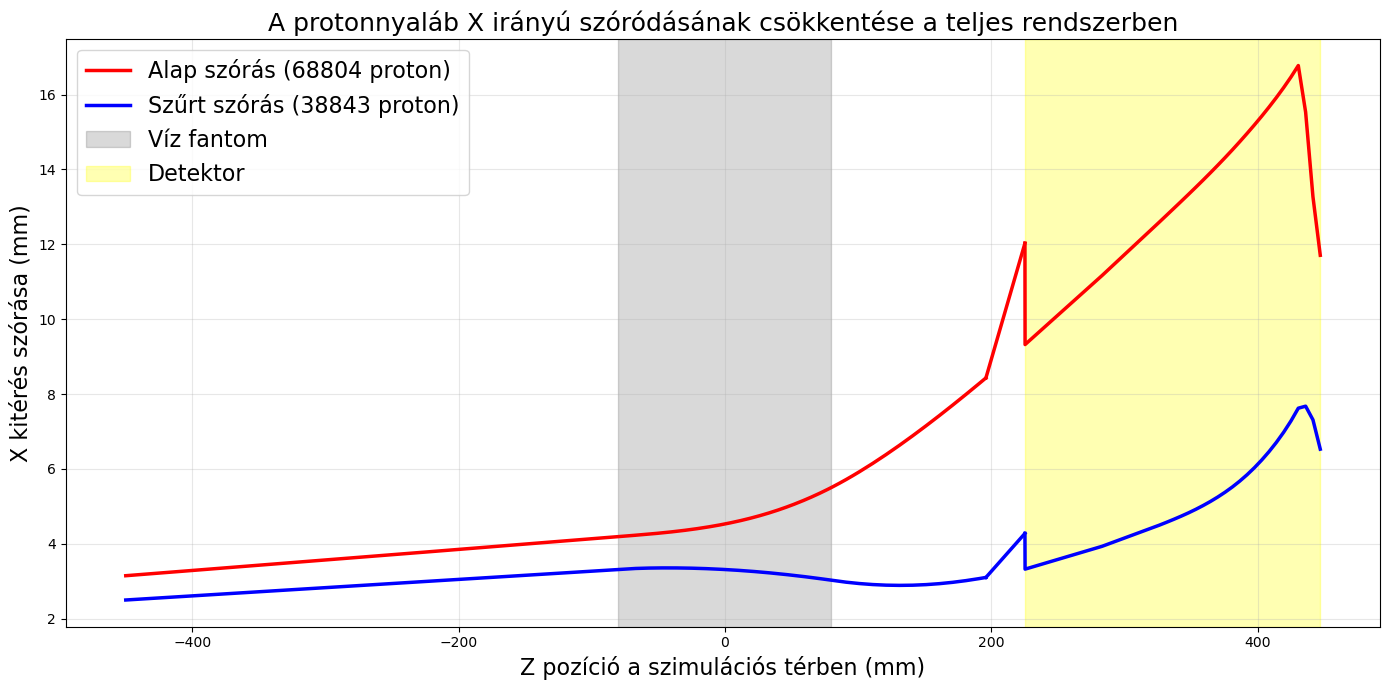

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

# ====================================================================
# 1. RÉSZ: PROTON RADIOGRÁFIA (2D VETÜLETI KÉP) GENERÁLÁSA
# ====================================================================
print("Proton Radiográfia (2D vetületi kép) generálása...")

bins_xy = 40 

ret_img = binned_statistic_2d(
    df_cut['X'], 
    df_cut['Y'], 
    df_cut['KineticEnergy'], 
    statistic='mean', 
    bins=bins_xy
)

plt.figure(figsize=(12, 10)) # Kicsit igazítottam az arányon, hogy jobban mutasson
extent = [ret_img.x_edge[0], ret_img.x_edge[-1], ret_img.y_edge[0], ret_img.y_edge[-1]]
im = plt.imshow(ret_img.statistic.T, origin='lower', extent=extent, cmap='viridis')

cbar = plt.colorbar(im)
cbar.set_label('Átlagos maradék energia (MeV)', fontsize=14)

plt.xlabel('X pozíció a detektoron (mm)', fontsize=14)
plt.ylabel('Y pozíció a detektoron (mm)', fontsize=14)
plt.title('A szűrt adatok ábrázolása (2D radiográfia)', fontsize=14, fontweight='bold')

plt.grid(False)
plt.show()

# ====================================================================
# 2. RÉSZ: SZÓRÓDÁS CSÖKKENÉSÉNEK BIZONYÍTÁSA (PIROS-KÉK ÁBRA)
# ====================================================================
print("\nStatisztika számítása a teljes detektorhosszra a 2D vágás alapján...")

# --- BIZTOSÍTÉK: PSA adatok újratöltése a Z-koordinátával együtt ---
particle = 'proton' # vagy ami a fájlod neve
PSAFile = f'PSA-{particle}.root'
with uproot.open(PSAFile) as file:
    df_psa = file[file.keys()[0]].arrays(library='pd')
df_psa = df_psa[df_psa['ParentID'] == 0] # Itt most szándékosan nem dobjuk el a Z oszlopot!

# --- ALAP (SZŰRETLEN) STATISZTIKA ---
valid_event_ids = df_hits_selected['EventID'].unique()

# PSA (fantom) alap szórás
df_psa_base = df_psa[df_psa['EventID'].isin(valid_event_ids)].copy()
df_psa_base['Z_slice'] = np.round(df_psa_base['PostPosition_Z'], 0)
std_base_psa = df_psa_base.groupby('Z_slice')['PostPosition_X'].std()

# Hits (detektor) alap szórás (CSAK HÁTSÓ DETEKTOROK)
df_hits_base = df_hits[df_hits['EventID'].isin(valid_event_ids)].copy()
df_hits_base = df_hits_base[df_hits_base['PostPosition_Z'] > 200] 
df_hits_base['Z_slice'] = np.round(df_hits_base['PostPosition_Z'], 1)
std_base_hits = df_hits_base.groupby('Z_slice')['PostPosition_X'].std().dropna()

# --- VÁGOTT (SZŰRT) STATISZTIKA A df_cut ALAPJÁN ---
# Itt kötjük össze a két ábrát: a df_cut-ban lévő EventID-kat kérjük le!
narrow_event_ids = df_cut['EventID'].unique()

# PSA (fantom) szűrt szórás
df_psa_narrow = df_psa[df_psa['EventID'].isin(narrow_event_ids)].copy()
df_psa_narrow['Z_slice'] = np.round(df_psa_narrow['PostPosition_Z'], 0)
std_narrow_psa = df_psa_narrow.groupby('Z_slice')['PostPosition_X'].std()

# Hits (detektor) szűrt szórás (CSAK HÁTSÓ DETEKTOROK)
df_hits_narrow_all = df_hits[df_hits['EventID'].isin(narrow_event_ids)].copy()
df_hits_narrow_all = df_hits_narrow_all[df_hits_narrow_all['PostPosition_Z'] > 200]
df_hits_narrow_all['Z_slice'] = np.round(df_hits_narrow_all['PostPosition_Z'], 1)
std_narrow_hits = df_hits_narrow_all.groupby('Z_slice')['PostPosition_X'].std().dropna()

print(f"Eredeti protonok száma: {len(valid_event_ids)} db")
print(f"Vágás utáni protonok száma: {len(narrow_event_ids)} db")

# --- ÁBRÁZOLÁS ---
plt.figure(figsize=(14, 7))

# --- PIROS VONALAK (Alap) ---
plt.plot(std_base_psa.index, std_base_psa.values, color='red', lw=2.5, label=f'Alap szórás ({len(valid_event_ids)} proton)')
plt.plot(std_base_hits.index, std_base_hits.values, color='red', lw=2.5)
plt.plot([std_base_psa.index[-1], std_base_hits.index[0]], [std_base_psa.values[-1], std_base_hits.values[0]], color='red', lw=2.5)

# --- KÉK VONALAK (Szűrt) ---
# Itt javítva lett a label a 2D vágásra!
plt.plot(std_narrow_psa.index, std_narrow_psa.values, color='blue', lw=2.5, label=f'Szűrt szórás ({len(narrow_event_ids)} proton)')
plt.plot(std_narrow_hits.index, std_narrow_hits.values, color='blue', lw=2.5)
plt.plot([std_narrow_psa.index[-1], std_narrow_hits.index[0]], [std_narrow_psa.values[-1], std_narrow_hits.values[0]], color='blue', lw=2.5)

# Dizájn elemek
plt.axvspan(-80, 80, color='black', alpha=0.15, label='Víz fantom')
plt.axvspan(std_base_hits.index.min(), std_base_hits.index.max(), color='yellow', alpha=0.30, label='Detektor')
plt.title('A protonnyaláb X irányú szóródásának csökkentése a teljes rendszerben', fontsize=18)
plt.xlabel('Z pozíció a szimulációs térben (mm)', fontsize=16)
plt.ylabel('X kitérés szórása (mm)', fontsize=16)
plt.legend(fontsize=16, loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

PSA adatok újratöltése a Z-koordinátával együtt...
Alap statisztika számítása a 'túlélő' protonokra...

Extra vágás (50%) kiszámítása...
Eredeti 'túlélő' protonok száma: 68804 db
Automatikus vágási határérték (|X| < ???): 5.19 mm
Megmaradt protonok száma (50% vágás után): 34402 db

Ábrázolás...


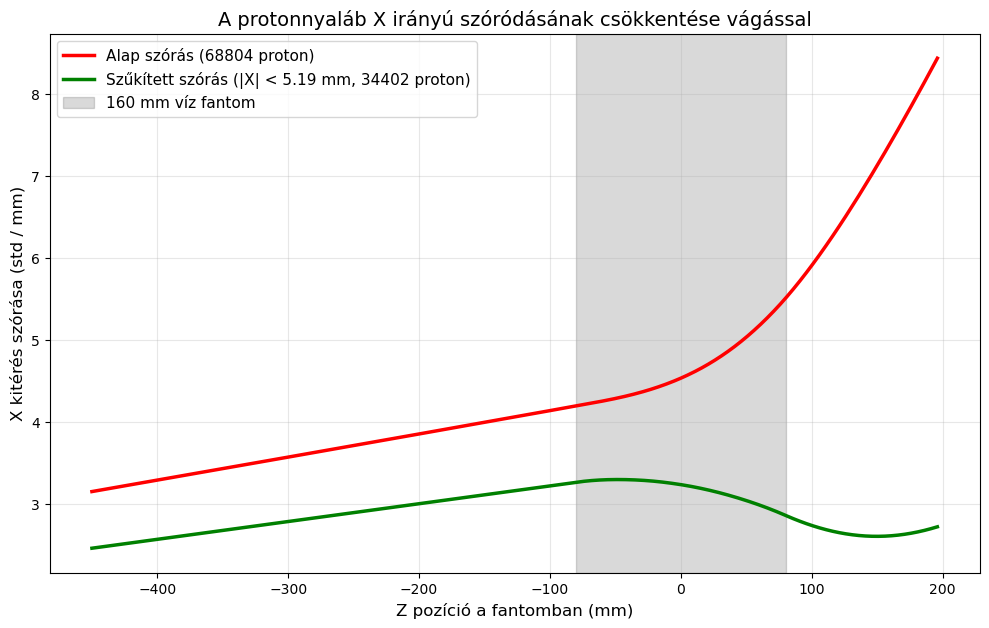

In [18]:
import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt

print("PSA adatok újratöltése a Z-koordinátával együtt...")
particle = 'proton'
PSAFile = f'PSA-{particle}.root'
with uproot.open(PSAFile) as file:
    df_psa = file[file.keys()[0]].arrays(library='pd')
df_psa = df_psa[df_psa['ParentID'] == 0] # Most megtartunk minden oszlopot!

print("Alap statisztika számítása a 'túlélő' protonokra...")
# 1. Alap szűrés: Csak azok az EventID-k kellenek a PSA-ból, amik beértek a detektorba
valid_event_ids = df_hits_selected['EventID'].unique()
df_psa_base = df_psa[df_psa['EventID'].isin(valid_event_ids)].copy()

# Z szeletek (Layer-ek) meghatározása
df_psa_base['Z_slice'] = np.round(df_psa_base['PostPosition_Z'], 0)
# Kiszámoljuk a szórást (std) minden Z szeletben
std_base = df_psa_base.groupby('Z_slice')['PostPosition_X'].std()

print("\nExtra vágás (50%) kiszámítása...")
# 2. Határozzuk meg a "???" értéket, ami lefelezi a létszámodat!
# A medián pontosan kettévágja az adatokat (50% alatta, 50% felette)
cut_value = df_hits_selected['X'].abs().median()

# Kiszűrjük azokat az EventID-kat, amik átmentek ezen a szigorú vágáson
df_hits_narrow = df_hits_selected[df_hits_selected['X'].abs() < cut_value]
narrow_event_ids = df_hits_narrow['EventID'].unique()

print(f"Eredeti 'túlélő' protonok száma: {len(valid_event_ids)} db")
print(f"Automatikus vágási határérték (|X| < ???): {cut_value:.2f} mm")
print(f"Megmaradt protonok száma (50% vágás után): {len(narrow_event_ids)} db")

# 3. A szűkített adatok szórásának kiszámítása a fantomban
df_psa_narrow = df_psa[df_psa['EventID'].isin(narrow_event_ids)].copy()
df_psa_narrow['Z_slice'] = np.round(df_psa_narrow['PostPosition_Z'], 0)
std_narrow = df_psa_narrow.groupby('Z_slice')['PostPosition_X'].std()

print("\nÁbrázolás...")
# 4. Ábrázolás
plt.figure(figsize=(12, 7))

# Csak a fantom területét ábrázoljuk
plt.plot(std_base.index, std_base.values, label=f'Alap szórás ({len(valid_event_ids)} proton)', color='red', lw=2.5)
plt.plot(std_narrow.index, std_narrow.values, label=f'Szűkített szórás (|X| < {cut_value:.2f} mm, {len(narrow_event_ids)} proton)', color='green', lw=2.5)

# Vízfantom határainak jelölése
plt.axvspan(-80, 80, color='black', alpha=0.15, label='160 mm víz fantom')

plt.title('A protonnyaláb X irányú szóródásának csökkentése vágással', fontsize=14)
plt.xlabel('Z pozíció a fantomban (mm)', fontsize=12)
plt.ylabel('X kitérés szórása (std / mm)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

Statisztika számítása a teljes detektorhosszra (Fantom + Detektor)...
Eredeti protonok száma: 68804 db
Vágás utáni protonok száma: 34402 db


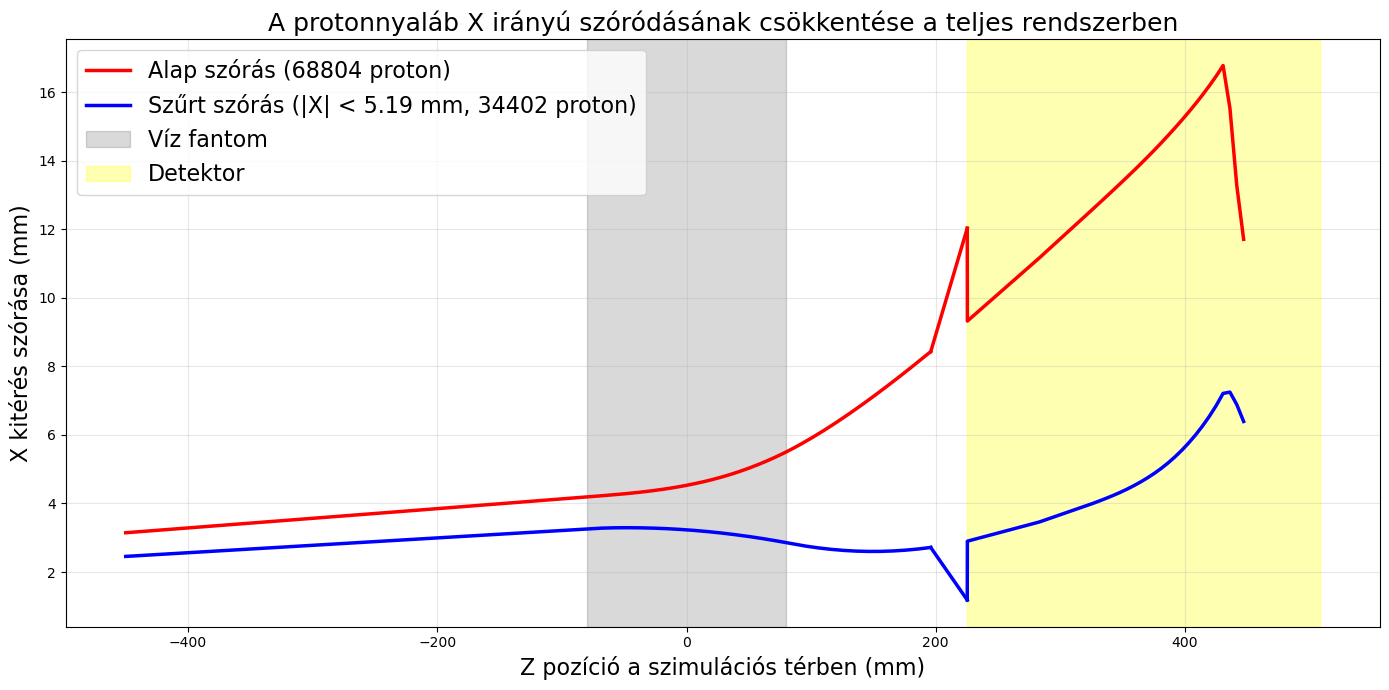

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Statisztika számítása a teljes detektorhosszra (Fantom + Detektor)...")

# --- 1. ALAP (SZŰRETLEN) STATISZTIKA ---
valid_event_ids = df_hits_selected['EventID'].unique()

# PSA (fantom) alap szórás
df_psa_base = df_psa[df_psa['EventID'].isin(valid_event_ids)].copy()
df_psa_base['Z_slice'] = np.round(df_psa_base['PostPosition_Z'], 0)
std_base_psa = df_psa_base.groupby('Z_slice')['PostPosition_X'].std()

# --- 1. ALAP (SZŰRETLEN) STATISZTIKA ---
df_hits_base = df_hits[df_hits['EventID'].isin(valid_event_ids)].copy()
df_hits_base = df_hits_base[df_hits_base['PostPosition_Z'] > 200] # CSAK A HÁTSÓ DETEKTOROK
df_hits_base['Z_slice'] = np.round(df_hits_base['PostPosition_Z'], 1)
std_base_hits = df_hits_base.groupby('Z_slice')['PostPosition_X'].std().dropna() # dropna a lyukak ellen

# ... (ugyanez a 2. VÁGOTT STATISZTIKÁNÁL) ...
df_hits_narrow_all = df_hits[df_hits['EventID'].isin(narrow_event_ids)].copy()
df_hits_narrow_all = df_hits_narrow_all[df_hits_narrow_all['PostPosition_Z'] > 200] # CSAK A HÁTSÓ DETEKTOROK
df_hits_narrow_all['Z_slice'] = np.round(df_hits_narrow_all['PostPosition_Z'], 1)
std_narrow_hits = df_hits_narrow_all.groupby('Z_slice')['PostPosition_X'].std().dropna()

# PSA (fantom) szűrt szórás
df_psa_narrow = df_psa[df_psa['EventID'].isin(narrow_event_ids)].copy()
df_psa_narrow['Z_slice'] = np.round(df_psa_narrow['PostPosition_Z'], 0)
std_narrow_psa = df_psa_narrow.groupby('Z_slice')['PostPosition_X'].std()

# Hits (detektor) szűrt szórás
df_hits_narrow_all = df_hits[df_hits['EventID'].isin(narrow_event_ids)].copy()
df_hits_narrow_all['Z_slice'] = np.round(df_hits_narrow_all['PostPosition_Z'], 1)
std_narrow_hits = df_hits_narrow_all.groupby('Z_slice')['PostPosition_X'].std()

print(f"Eredeti protonok száma: {len(valid_event_ids)} db")
print(f"Vágás utáni protonok száma: {len(narrow_event_ids)} db")

# --- 3. ÁBRÁZOLÁS ---
plt.figure(figsize=(14, 7))

# --- PIROS VONALAK (Alap) ---
# Fantom szakasz
plt.plot(std_base_psa.index, std_base_psa.values, color='red', lw=2.5, label=f'Alap szórás ({len(valid_event_ids)} proton)')
# Detektor szakasz (legyen kicsit halványabb vagy szaggatott, hogy látszódjon a különbség a közegek között)
plt.plot(std_base_hits.index, std_base_hits.values, color='red', lw=2.5)
# Híd a PSA és Hits között
plt.plot([std_base_psa.index[-1], std_base_hits.index[0]], [std_base_psa.values[-1], std_base_hits.values[0]], color='red', lw=2.5)

# --- KÉK VONALAK (Szűrt) ---
# Fantom szakasz
plt.plot(std_narrow_psa.index, std_narrow_psa.values, color='blue', lw=2.5, label=f'Szűrt szórás (|X| < {cut_value:.2f} mm, {len(narrow_event_ids)} proton)')
# Detektor szakasz
plt.plot(std_narrow_hits.index, std_narrow_hits.values, color='blue', lw=2.5)
# Híd a PSA és Hits között
plt.plot([std_narrow_psa.index[-1], std_narrow_hits.index[0]], [std_narrow_psa.values[-1], std_narrow_hits.values[0]], color='blue', lw=2.5)

# Dizájn elemek
plt.axvspan(-80, 80, color='black', alpha=0.15, label='Víz fantom')
plt.axvspan(std_base_hits.index.min(), std_base_hits.index.min() + 57.8 + 41 * 5.5, color='yellow', alpha=0.30, label='Detektor')
plt.title('A protonnyaláb X irányú szóródásának csökkentése a teljes rendszerben', fontsize=18)
plt.xlabel('Z pozíció a szimulációs térben (mm)', fontsize=16)
plt.ylabel('X kitérés szórása (mm)', fontsize=16)
plt.legend(fontsize=16, loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()